# TensiMenu | Preprocessing & Feature Engineering

**Dataset**: TKPI 2017 (Tabel Komposisi Pangan Indonesia) — 1.146 item makanan

**Tujuan notebook ini:**
1. Loading & cleaning dataset TKPI 2017
2. EDA: distribusi nutrisi, missing values, korelasi
3. Preprocessing: konversi tipe data, imputasi, filtering
4. Feature engineering:
   - Adaptasi fitur DASH sesuai kolom yang tersedia di TKPI
   - Formula target nutrisi personal (Mifflin-St Jeor)
   - Formula DASH Compliance Score
5. Normalisasi & Item Feature Matrix
6. Content-Based Filtering (Cosine Similarity)
7. Simpan artefak model

---

### Catatan Penting tentang Dataset TKPI 2017

TKPI **tidak memiliki** kolom `magnesium_mg` dan `fat_saturated_g`. Fitur DASH yang tersedia:

| Fitur DASH (Ideal) | Kolom TKPI | Status |
|---|---|---|
| `sodium_mg` | `NATRIUM_mg` | ✅ Tersedia (562/1146 non-null) |
| `potassium_mg` | `KALIUM_mg` | ✅ Tersedia (450/1146 non-null) |
| `calcium_mg` | `KALSIUM_mg` | ✅ Tersedia (733/1146 non-null) |
| `fiber_g` | `SERAT_g` | ✅ Tersedia (785/1146 non-null) |
| `fat_total_g` | `LEMAK_g` | ✅ Tersedia (1049/1146 non-null) |
| `magnesium_mg` | — | ❌ Tidak ada |
| `fat_saturated_g` | — | ❌ Tidak ada |

**Strategi**: Gunakan 5 fitur DASH yang tersedia. Total **5 fitur inti DASH** untuk cosine similarity.

**Catatan DASH Score**: Score dihitung secara *relatif* - membandingkan nutrisi per sajian terhadap target harian. Ini menghasilkan ranking yang valid untuk perbandingan antar item, meskipun skor absolut bukan persentase pemenuhan harian.

## 0. Setup & Konfigurasi

In [1]:
# Install dependensi
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
# Upload file jika di Google Colab
try:
    from google.colab import files
    uploaded = files.upload()  # Upload TKPI_2017_dataset  .csv
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Bukan di Colab — skip upload.')

Saving TKPI_2017_dataset  .csv to TKPI_2017_dataset  .csv


In [3]:
import json
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Plot config
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 12

# Output
ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

MODEL_VERSION = '1.0.0'
print(f'NumPy {np.__version__} | Pandas {pd.__version__} | Seed: {RANDOM_STATE}')

NumPy 2.0.2 | Pandas 2.2.2 | Seed: 42


## 1. Loading Dataset TKPI 2017

In [4]:
# Path dataset
# Di Colab: file sudah di-upload ke working directory
# Di lokal: sesuaikan path relatif
if IN_COLAB:
    DATA_PATH = 'TKPI_2017_dataset  .csv'
else:
    DATA_PATH = '../datasets/TKPI_2017_dataset  .csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset dimuat: {df_raw.shape[0]} baris \u00d7 {df_raw.shape[1]} kolom')
print(f'Kolom: {df_raw.columns.tolist()}')
df_raw.head()

Dataset dimuat: 1146 baris × 26 kolom
Kolom: ['KODE', 'NAMA_BAHAN', 'KATEGORI', 'SUMBER', 'AIR_g', 'ENERGI_kal', 'PROTEIN_g', 'LEMAK_g', 'KH_g', 'SERAT_g', 'ABU_g', 'KALSIUM_mg', 'FOSFOR_mg', 'BESI_mg', 'NATRIUM_mg', 'KALIUM_mg', 'TEMBAGA_mg', 'SENG_mg', 'RETINOL_mcg', 'BKAROTEN_mcg', 'KARTOTAL_mcg', 'THIAMIN_mg', 'RIBOFLAVIN_mg', 'NIASIN_mg', 'VIT_C_mg', 'BDD_pct']


,KODE,NAMA_BAHAN,KATEGORI,SUMBER,AIR_g,ENERGI_kal,PROTEIN_g,LEMAK_g,KH_g,SERAT_g,...,TEMBAGA_mg,SENG_mg,RETINOL_mcg,BKAROTEN_mcg,KARTOTAL_mcg,THIAMIN_mg,RIBOFLAVIN_mg,NIASIN_mg,VIT_C_mg,BDD_pct
0,AR001,"Beras giling, mentah",Serealia,KZGMI-2001,12.0,357,8.4,1.7,77.1,0.2,...,0.10,0.5,0.0,0.0,0,0.20,0.08,2.6,0.0,100
1,AR002,"Beras giling var pelita, mentah",Serealia,KZGPI- 1990,11.4,369,9.5,1.4,77.1,0.4,...,0.00,0.0,0.0,0.0,0,0.26,0.00,0.0,0.0,100
2,AR003,"Beras giling var rojolele, mentah",Serealia,KZGPI- 1990,12.0,357,8.4,1.7,77.1,0.2,...,0.14,0.1,NaN,0.0,80,0.20,0.02,1.5,0.0,100
3,AR004,"Beras hitam, mentah",Serealia,KZGMI-2001,12.9,351,8.0,1.3,76.9,20.1,...,0.10,1.6,0.0,0.0,0,0.21,0.06,0.0,0.0,100
4,AR005,"Beras jagung kuning, kering, mentah",Serealia,KZGMI-2001,10.8,358,5.5,0.1,82.7,10.0,...,0.10,4.1,NaN,641.0,NaN,0.12,0.08,1.0,3.0,100


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1146 entries, 0 to 1145
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   KODE           1146 non-null   object 
 1   NAMA_BAHAN     1146 non-null   object 
 2   KATEGORI       1146 non-null   object 
 3   SUMBER         1146 non-null   object 
 4   AIR_g          965 non-null    float64
 5   ENERGI_kal     1146 non-null   int64  
 6   PROTEIN_g      1012 non-null   object 
 7   LEMAK_g        1049 non-null   float64
 8   KH_g           934 non-null    float64
 9   SERAT_g        785 non-null    float64
 10  ABU_g          536 non-null    object 
 11  KALSIUM_mg     734 non-null    object 
 12  FOSFOR_mg      560 non-null    float64
 13  BESI_mg        433 non-null    object 
 14  NATRIUM_mg     563 non-null    object 
 15  KALIUM_mg      450 non-null    float64
 16  TEMBAGA_mg     290 non-null    object 
 17  SENG_mg        195 non-null    float64
 18  RETINOL_

## 2. Preprocessing: Konversi Tipe Data & Cleaning

Beberapa kolom numerik terbaca sebagai `object` karena ada karakter non-numerik. Kita konversi ke float.

In [6]:
# Kolom yang seharusnya numerik tapi terbaca object
NUMERIC_COLS = [
    'PROTEIN_g', 'ABU_g', 'KALSIUM_mg', 'BESI_mg',
    'NATRIUM_mg', 'TEMBAGA_mg', 'KARTOTAL_mcg',
    'THIAMIN_mg', 'RIBOFLAVIN_mg', 'NIASIN_mg', 'BDD_pct'
]

df = df_raw.copy()

for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Konversi tipe data selesai.')
print(f'Dtypes setelah konversi:')
print(df[NUMERIC_COLS].dtypes.to_string())

Konversi tipe data selesai.
Dtypes setelah konversi:
PROTEIN_g        float64
ABU_g            float64
KALSIUM_mg       float64
BESI_mg          float64
NATRIUM_mg       float64
TEMBAGA_mg       float64
KARTOTAL_mcg     float64
THIAMIN_mg       float64
RIBOFLAVIN_mg    float64
NIASIN_mg        float64
BDD_pct          float64


In [7]:
# Rename kolom ke format standar (snake_case, English)
COLUMN_MAP = {
    'KODE': 'food_code',
    'NAMA_BAHAN': 'name',
    'KATEGORI': 'category',
    'SUMBER': 'data_source',
    'AIR_g': 'water_g',
    'ENERGI_kal': 'energy_kcal',
    'PROTEIN_g': 'protein_g',
    'LEMAK_g': 'fat_total_g',
    'KH_g': 'carbs_g',
    'SERAT_g': 'fiber_g',
    'ABU_g': 'ash_g',
    'KALSIUM_mg': 'calcium_mg',
    'FOSFOR_mg': 'phosphorus_mg',
    'BESI_mg': 'iron_mg',
    'NATRIUM_mg': 'sodium_mg',
    'KALIUM_mg': 'potassium_mg',
    'TEMBAGA_mg': 'copper_mg',
    'SENG_mg': 'zinc_mg',
    'RETINOL_mcg': 'retinol_mcg',
    'BKAROTEN_mcg': 'beta_carotene_mcg',
    'KARTOTAL_mcg': 'carotene_total_mcg',
    'THIAMIN_mg': 'thiamin_mg',
    'RIBOFLAVIN_mg': 'riboflavin_mg',
    'NIASIN_mg': 'niacin_mg',
    'VIT_C_mg': 'vitamin_c_mg',
    'BDD_pct': 'edible_portion_pct',
}

df = df.rename(columns=COLUMN_MAP)
print(f'Kolom setelah rename: {df.columns.tolist()}')

Kolom setelah rename: ['food_code', 'name', 'category', 'data_source', 'water_g', 'energy_kcal', 'protein_g', 'fat_total_g', 'carbs_g', 'fiber_g', 'ash_g', 'calcium_mg', 'phosphorus_mg', 'iron_mg', 'sodium_mg', 'potassium_mg', 'copper_mg', 'zinc_mg', 'retinol_mcg', 'beta_carotene_mcg', 'carotene_total_mcg', 'thiamin_mg', 'riboflavin_mg', 'niacin_mg', 'vitamin_c_mg', 'edible_portion_pct']


## 3. Definisi Fitur DASH (Disesuaikan dengan TKPI)

| Fitur | Arah | Bobot | Alasan |
|-------|------|-------|--------|
| `sodium_mg` | Lower is better | 0.30 | Faktor utama hipertensi |
| `potassium_mg` | Higher is better | 0.25 | Counterbalance natrium |
| `calcium_mg` | Higher is better | 0.20 | Penting untuk DASH |
| `fiber_g` | Higher is better | 0.15 | Kesehatan kardiovaskular |
| `fat_total_g` | Lower is better | 0.10 | Proxy lemak jenuh |

In [8]:
# Fitur DASH yang tersedia di TKPI
DASH_FEATURES = [
    'sodium_mg',      # Negatif: lebih rendah lebih baik
    'potassium_mg',   # Positif: lebih tinggi lebih baik
    'calcium_mg',     # Positif
    'fiber_g',        # Positif
    'fat_total_g',    # Negatif
]

# Bobot nutrisi untuk DASH Score (total = 1.0)
NUTRIENT_WEIGHTS = {
    'sodium_mg':    {'direction': 'lower',  'weight': 0.30},
    'potassium_mg': {'direction': 'higher', 'weight': 0.25},
    'calcium_mg':   {'direction': 'higher', 'weight': 0.20},
    'fiber_g':      {'direction': 'higher', 'weight': 0.15},
    'fat_total_g':  {'direction': 'lower',  'weight': 0.10},
}

total_weight = sum(v['weight'] for v in NUTRIENT_WEIGHTS.values())
assert abs(total_weight - 1.0) < 1e-9, f'Bobot harus 1.0, dapat {total_weight}'
print(f'\u2713 {len(DASH_FEATURES)} fitur DASH terdefinisi. Total bobot: {total_weight:.2f}')

✓ 5 fitur DASH terdefinisi. Total bobot: 1.00


## 4. EDA (Exploratory Data Analysis)

In [9]:
# Missing values per kolom DASH
print('=== MISSING VALUES FITUR DASH ===')
for feat in DASH_FEATURES:
    n_miss = df[feat].isnull().sum()
    pct = n_miss / len(df) * 100
    print(f'  {feat:15s}: {n_miss:4d} missing ({pct:.1f}%)')

print(f'\nTotal baris: {len(df)}')
mask_all = df[DASH_FEATURES].notna().all(axis=1)
print(f'Baris dengan SEMUA fitur DASH lengkap: {mask_all.sum()}')

=== MISSING VALUES FITUR DASH ===
  sodium_mg      :  584 missing (51.0%)
  potassium_mg   :  696 missing (60.7%)
  calcium_mg     :  413 missing (36.0%)
  fiber_g        :  361 missing (31.5%)
  fat_total_g    :   97 missing (8.5%)

Total baris: 1146
Baris dengan SEMUA fitur DASH lengkap: 46


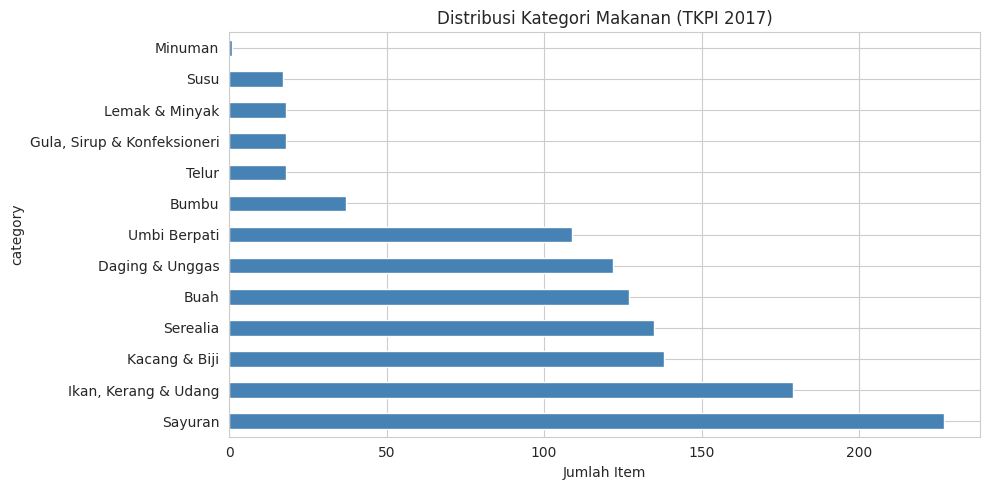

In [10]:
# Distribusi kategori makanan
fig, ax = plt.subplots(figsize=(10, 5))
df['category'].value_counts().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Distribusi Kategori Makanan (TKPI 2017)')
ax.set_xlabel('Jumlah Item')
plt.tight_layout()
plt.show()

In [11]:
# Statistik deskriptif fitur DASH
print('=== STATISTIK DESKRIPTIF FITUR DASH (per 100g) ===')
df[DASH_FEATURES].describe().round(2)

=== STATISTIK DESKRIPTIF FITUR DASH (per 100g) ===


,sodium_mg,potassium_mg,calcium_mg,fiber_g,fat_total_g
count,562.00,450.00,733.00,785.00,1049.00
mean,58.27,79.63,70.88,5.50,8.85
std,374.20,233.75,129.34,17.45,15.86
min,0.00,0.00,0.00,0.00,0.00
25%,0.50,3.00,2.40,0.10,0.70
50%,2.00,17.00,20.00,1.60,2.70
75%,5.95,65.75,85.00,4.20,9.10
max,6227.00,3492.00,1125.00,280.00,100.00


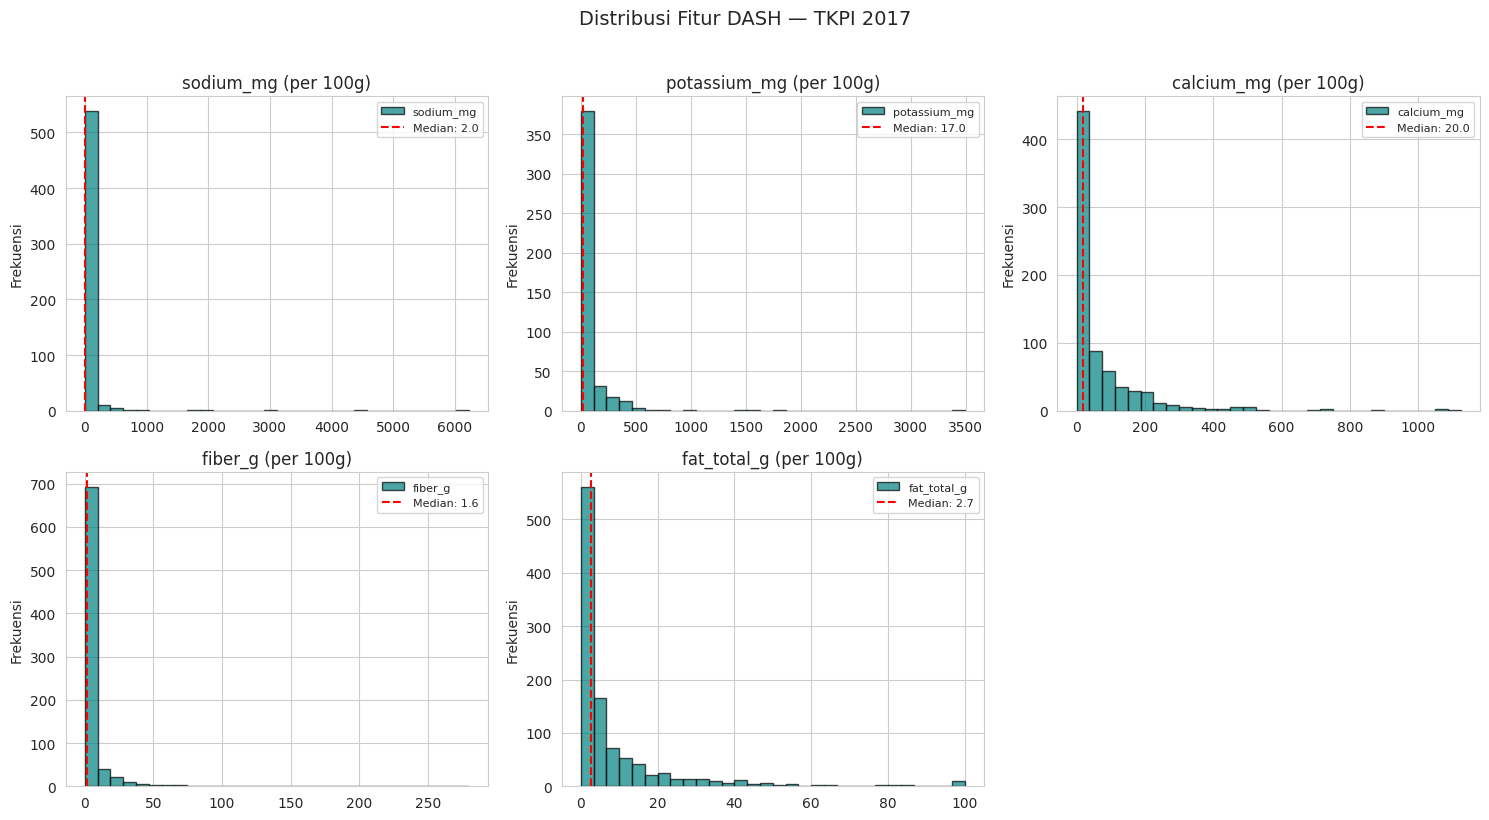

In [12]:
# Distribusi fitur DASH (histogram)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, feat in enumerate(DASH_FEATURES):
    ax = axes[idx // 3, idx % 3]
    df[feat].dropna().plot(kind='hist', bins=30, ax=ax, color='teal', edgecolor='black', alpha=0.7)
    ax.set_title(f'{feat} (per 100g)')
    ax.set_ylabel('Frekuensi')
    ax.axvline(df[feat].median(), color='red', linestyle='--', label=f'Median: {df[feat].median():.1f}')
    ax.legend(fontsize=8)
axes[1, 2].axis('off')
plt.suptitle('Distribusi Fitur DASH \u2014 TKPI 2017', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

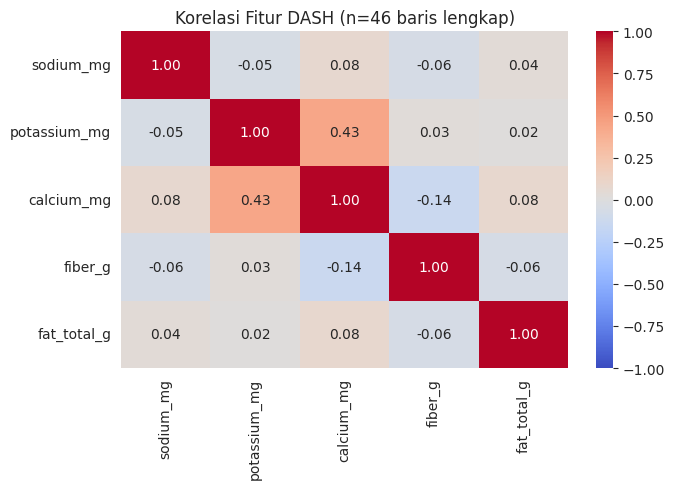

In [13]:
# Korelasi antar fitur DASH (hanya baris lengkap)
df_complete = df[DASH_FEATURES].dropna()
corr = df_complete.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title(f'Korelasi Fitur DASH (n={len(df_complete)} baris lengkap)')
plt.tight_layout()
plt.show()

## 5. Filtering & Imputasi

**Strategi:**
1. Filter kategori makanan relevan (buang Bumbu, Minuman, Lemak & Minyak, Gula)
2. Filter baris dengan minimal 3/5 fitur DASH non-null
3. Imputasi missing values: median per kategori (fallback: median global)
4. Validasi: semua nilai >= 0

In [14]:
# Kategori yang relevan untuk rekomendasi makanan
RELEVANT_CATEGORIES = [
    'Serealia',
    'Umbi Berpati',
    'Kacang & Biji',
    'Sayuran',
    'Buah',
    'Daging & Unggas',
    'Ikan, Kerang & Udang',
    'Telur',
    'Susu',
]

df_filtered = df[df['category'].isin(RELEVANT_CATEGORIES)].copy()
print(f'Setelah filter kategori: {len(df_filtered)} item (dari {len(df)})')
print(f'Kategori dibuang: Bumbu, Minuman, Lemak & Minyak, Gula/Sirup')

Setelah filter kategori: 1072 item (dari 1146)
Kategori dibuang: Bumbu, Minuman, Lemak & Minyak, Gula/Sirup


In [15]:
# Filter: minimal 3 dari 5 fitur DASH harus non-null
MIN_FEATURES_REQUIRED = 3
dash_non_null_count = df_filtered[DASH_FEATURES].notna().sum(axis=1)
df_filtered = df_filtered[dash_non_null_count >= MIN_FEATURES_REQUIRED].copy()
print(f'Setelah filter min {MIN_FEATURES_REQUIRED} fitur DASH: {len(df_filtered)} item')

Setelah filter min 3 fitur DASH: 792 item


In [16]:
# Imputasi: median per kategori, fallback median global
def impute_by_category(df, features, group_col='category'):
    """Imputasi missing values dengan median per kategori."""
    df = df.copy()
    for feat in features:
        df[feat] = df.groupby(group_col)[feat].transform(
            lambda s: s.fillna(s.median())
        )
        global_median = df[feat].median()
        df[feat] = df[feat].fillna(global_median)
    return df

df_clean = impute_by_category(df_filtered, DASH_FEATURES)

remaining_na = df_clean[DASH_FEATURES].isnull().sum().sum()
assert remaining_na == 0, f'Masih ada {remaining_na} missing values'
print(f'\u2713 Imputasi selesai. 0 missing values di fitur DASH.')
print(f'  Dataset final: {len(df_clean)} item makanan')

✓ Imputasi selesai. 0 missing values di fitur DASH.
  Dataset final: 792 item makanan


In [17]:
# Validasi: semua nilai >= 0
for feat in DASH_FEATURES:
    neg_count = (df_clean[feat] < 0).sum()
    if neg_count > 0:
        print(f'  \u26a0 {feat}: {neg_count} nilai negatif \u2014 di-clip ke 0')
        df_clean[feat] = df_clean[feat].clip(lower=0)

print('\u2713 Semua fitur DASH non-negatif.')
print()
print('=== DATASET FINAL PER KATEGORI ===')
print(df_clean['category'].value_counts().to_string())
print(f'\nTotal: {len(df_clean)} item')

✓ Semua fitur DASH non-negatif.

=== DATASET FINAL PER KATEGORI ===
category
Sayuran                 219
Kacang & Biji           123
Ikan, Kerang & Udang    116
Umbi Berpati            107
Serealia                 93
Daging & Unggas          77
Buah                     44
Susu                     13

Total: 792 item


## 6. Feature Engineering

### 6.1 Target Nutrisi Personal (Mifflin-St Jeor + Penyesuaian Komorbid)

In [18]:
def calculate_personal_targets(profile: dict) -> dict:
    """
    Hitung target nutrisi harian personal.
    Rumus BMR (Mifflin-St Jeor):
      Laki-laki: BMR = (10*BB) + (6.25*TB) - (5*usia) + 5
      Perempuan: BMR = (10*BB) + (6.25*TB) - (5*usia) - 161
    """
    weight = profile['weight_kg']
    height = profile['height_cm']
    age = profile['age']
    gender = profile['gender']
    comorbidities = profile.get('comorbidities', [])
    systolic_bp = profile.get('systolic_bp')

    if gender == 'laki-laki':
        bmr = (10 * weight) + (6.25 * height) - (5 * age) + 5
    else:
        bmr = (10 * weight) + (6.25 * height) - (5 * age) - 161

    targets = {
        'sodium_mg': 2300.0,
        'potassium_mg': 4000.0,
        'calcium_mg': 1200.0 if age > 50 else 1000.0,
        'fiber_g': 38.0 if gender == 'laki-laki' else 25.0,
        'fat_total_g': round(bmr * 0.27 / 9, 1),
        'energy_kcal': round(bmr),
        'phosphorus_mg': 1250.0,
    }

    if 'ckd' in comorbidities:
        targets['sodium_mg'] = 1500.0
        targets['potassium_mg'] = 2000.0
        targets['phosphorus_mg'] = 800.0

    if systolic_bp is not None and systolic_bp >= 150:
        targets['sodium_mg'] = 1500.0

    return targets


SAMPLE_PROFILES = [
    {'gender': 'laki-laki', 'weight_kg': 70, 'height_cm': 170, 'age': 45,
     'comorbidities': [], 'systolic_bp': 140},
    {'gender': 'perempuan', 'weight_kg': 60, 'height_cm': 158, 'age': 55,
     'comorbidities': ['ckd'], 'systolic_bp': 160},
    {'gender': 'laki-laki', 'weight_kg': 85, 'height_cm': 175, 'age': 35,
     'comorbidities': ['diabetes_t2'], 'systolic_bp': 135},
]

print('=== TARGET NUTRISI PERSONAL ===')
for i, p in enumerate(SAMPLE_PROFILES):
    t = calculate_personal_targets(p)
    print(f'\nProfil {i+1}: {p["gender"]}, {p["age"]}th, {p["weight_kg"]}kg, komorbid={p["comorbidities"]}')
    for k, v in t.items():
        print(f'  {k:18s}: {v}')

=== TARGET NUTRISI PERSONAL ===

Profil 1: laki-laki, 45th, 70kg, komorbid=[]
  sodium_mg         : 2300.0
  potassium_mg      : 4000.0
  calcium_mg        : 1000.0
  fiber_g           : 38.0
  fat_total_g       : 46.3
  energy_kcal       : 1542
  phosphorus_mg     : 1250.0

Profil 2: perempuan, 55th, 60kg, komorbid=['ckd']
  sodium_mg         : 1500.0
  potassium_mg      : 2000.0
  calcium_mg        : 1200.0
  fiber_g           : 25.0
  fat_total_g       : 34.5
  energy_kcal       : 1152
  phosphorus_mg     : 800.0

Profil 3: laki-laki, 35th, 85kg, komorbid=['diabetes_t2']
  sodium_mg         : 2300.0
  potassium_mg      : 4000.0
  calcium_mg        : 1000.0
  fiber_g           : 38.0
  fat_total_g       : 53.2
  energy_kcal       : 1774
  phosphorus_mg     : 1250.0


### 6.2 DASH Compliance Score per Item Makanan

In [19]:
def calculate_dash_score(nutrition_per_serving: dict, user_targets: dict) -> float:
    """
    Hitung DASH Score (0-100) untuk satu sajian makanan.
    Score bersifat RELATIF (ranking antar item), bukan persentase pemenuhan harian.
    Deterministik: input sama = output sama.
    """
    total_score = 0.0

    for nutrient, config in NUTRIENT_WEIGHTS.items():
        actual = nutrition_per_serving.get(nutrient, 0.0)
        target = user_targets.get(nutrient, 1.0)
        weight = config['weight']

        if target <= 0:
            contribution = 0.0
        elif config['direction'] == 'higher':
            contribution = min(actual / target, 1.0)
        else:
            if actual <= target:
                contribution = 1.0
            else:
                contribution = max(0.0, 1.0 - (actual - target) / target)

        total_score += contribution * weight

    return round(total_score * 100, 1)


def get_dash_category(score: float) -> str:
    """Klasifikasi DASH Score ke label."""
    if score >= 80:
        return 'Sangat Baik'
    elif score >= 60:
        return 'Baik'
    elif score >= 40:
        return 'Cukup'
    else:
        return 'Perlu Perhatian'


# Verifikasi properti: skor selalu [0, 100]
test_targets = calculate_personal_targets(SAMPLE_PROFILES[0])
for _ in range(1000):
    rand_nutr = {f: np.random.uniform(0, 2000) for f in DASH_FEATURES}
    s = calculate_dash_score(rand_nutr, test_targets)
    assert 0 <= s <= 100, f'Skor di luar range: {s}'
print('\u2713 DASH Score selalu dalam [0, 100] (1000 sampel acak)')

✓ DASH Score selalu dalam [0, 100] (1000 sampel acak)


In [20]:
# Hitung DASH Score per item (asumsi porsi 100g untuk scoring relatif)
sample_targets = calculate_personal_targets(SAMPLE_PROFILES[0])
SERVING_SIZE_G = 100.0

def get_nutrition_per_serving(row, serving_g=SERVING_SIZE_G):
    factor = serving_g / 100.0
    return {feat: row[feat] * factor for feat in DASH_FEATURES}

df_clean['dash_score'] = df_clean.apply(
    lambda r: calculate_dash_score(get_nutrition_per_serving(r), sample_targets), axis=1
)
df_clean['dash_category'] = df_clean['dash_score'].apply(get_dash_category)

print('=== DISTRIBUSI DASH SCORE ===')
print(df_clean['dash_category'].value_counts().to_string())
print(f'\nMean: {df_clean["dash_score"].mean():.1f} | Median: {df_clean["dash_score"].median():.1f}')

=== DISTRIBUSI DASH SCORE ===
dash_category
Cukup              782
Perlu Perhatian      5
Baik                 5

Mean: 43.1 | Median: 41.7


In [21]:
# Top 15 makanan DASH Score tertinggi
print('=== TOP 15 MAKANAN DASH SCORE TERTINGGI ===')
df_clean.nlargest(15, 'dash_score')[['name', 'category', 'dash_score', 'dash_category']]

=== TOP 15 MAKANAN DASH SCORE TERTINGGI ===


,name,category,dash_score,dash_category
301,"Kacang kedelai, goreng",Kacang & Biji,70.7,Baik
292,"Lamtoro var, lokal dengan kulit",Kacang & Biji,64.3,Baik
419,"Daun kelor, segar",Sayuran,63.6,Baik
294,"Saga merah terkupas, mentah",Kacang & Biji,61.8,Baik
295,"Wijen, mentah",Kacang & Biji,60.5,Baik
265,"Kacang lebui /iris, kering",Kacang & Biji,57.7,Cukup
468,"Jamur kuping, kering",Sayuran,57.1,Cukup
447,"Daun pohpohan, segar",Sayuran,56.0,Cukup
429,"Daun lamtoro, segar",Sayuran,55.9,Cukup
534,"Tekokak, kering",Sayuran,55.9,Cukup


In [22]:
# Bottom 10 makanan
print('=== BOTTOM 10 MAKANAN DASH SCORE TERENDAH ===')
df_clean.nsmallest(10, 'dash_score')[['name', 'category', 'sodium_mg', 'fat_total_g', 'dash_score', 'dash_category']]

=== BOTTOM 10 MAKANAN DASH SCORE TERENDAH ===


,name,category,sodium_mg,fat_total_g,dash_score,dash_category
959,"Ikan lomak asin, mentah","Ikan, Kerang & Udang",6227.00,2.3,13.5,Perlu Perhatian
956,"Ikan katombo, asin","Ikan, Kerang & Udang",4393.00,2.8,15.3,Perlu Perhatian
43,Misoa,Serealia,3064.00,2.2,31.5,Perlu Perhatian
281,"Kenari, kering",Kacang & Biji,1.10,66.0,38.9,Perlu Perhatian
280,"Kenari banda, kering",Kacang & Biji,1.10,56.2,39.2,Perlu Perhatian
739,"Angsa, daging, segar",Daging & Unggas,0.26,0.0,40.0,Cukup
740,"Ayam, daging, segar",Daging & Unggas,0.11,0.0,40.0,Cukup
743,"Babi, daging, gemuk,segar",Daging & Unggas,0.22,0.0,40.0,Cukup
744,"Babi, daging, kurus, segar",Daging & Unggas,0.19,0.0,40.0,Cukup
747,"Bebek (itik), daging, segar",Daging & Unggas,0.21,0.0,40.0,Cukup


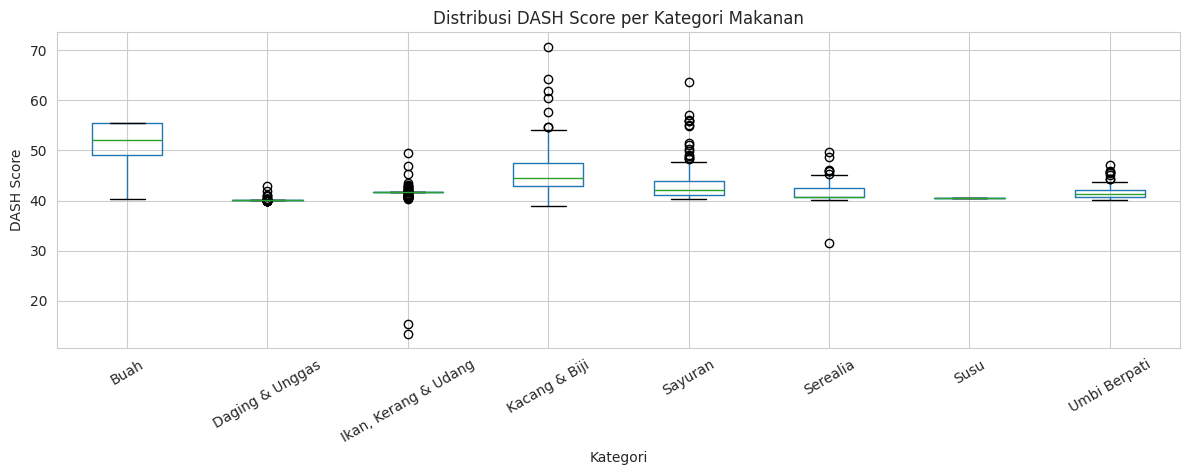

In [23]:
# Distribusi DASH Score per kategori
fig, ax = plt.subplots(figsize=(12, 5))
df_clean.boxplot(column='dash_score', by='category', ax=ax, rot=30)
ax.set_title('Distribusi DASH Score per Kategori Makanan')
ax.set_xlabel('Kategori')
ax.set_ylabel('DASH Score')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 7. Content-Based Filtering + Normalisasi

Satu class `ContentBasedFilter` yang mengelola scaler dan item matrix secara terpadu.
Artefak yang disimpan berasal dari class ini (bukan scaler terpisah).

In [24]:
def build_user_nutrition_vector(targets: dict) -> np.ndarray:
    """Konversi target nutrisi personal ke vektor numpy 5-dimensi."""
    return np.array([targets[f] for f in DASH_FEATURES], dtype=np.float64)


class ContentBasedFilter:
    """
    Content-Based Filtering untuk rekomendasi makanan DASH.
    Mengelola scaler + item_matrix dalam satu objek.
    """

    def __init__(self, random_state: int = 42):
        self.random_state = random_state
        self.scaler = None
        self.item_matrix = None
        self.food_ids = None
        self.features = DASH_FEATURES

    def fit(self, df: pd.DataFrame, id_col: str = 'food_code'):
        """Latih scaler dan buat item feature matrix."""
        self.scaler = StandardScaler()
        X = df[self.features].to_numpy(dtype=np.float64)
        self.item_matrix = self.scaler.fit_transform(X)
        self.food_ids = df[id_col].tolist()
        return self

    def recommend(self, user_targets: dict, df: pd.DataFrame,
                  top_k: int = 10, category_filter: str = None,
                  exclude_ids: list = None) -> pd.DataFrame:
        """Hasilkan rekomendasi berdasarkan cosine similarity."""
        user_vec = build_user_nutrition_vector(user_targets)
        user_vec_scaled = self.scaler.transform(user_vec.reshape(1, -1))
        similarities = cosine_similarity(user_vec_scaled, self.item_matrix)[0]

        result = df.copy()
        result['similarity'] = similarities

        if category_filter:
            result = result[result['category'] == category_filter]
        if exclude_ids:
            result = result[~result['food_code'].isin(exclude_ids)]

        result = result.sort_values('similarity', ascending=False).head(top_k)
        return result[['food_code', 'name', 'category', 'similarity', 'dash_score', 'dash_category']]


# Fit model (satu-satunya scaler yang digunakan)
cbf = ContentBasedFilter(random_state=RANDOM_STATE)
cbf.fit(df_clean)

print(f'\u2713 Model CBF terlatih: {len(cbf.food_ids)} item, {len(cbf.features)} fitur')
print(f'  Item matrix shape: {cbf.item_matrix.shape}')
print(f'  Mean per fitur (\u22480): {cbf.item_matrix.mean(axis=0).round(4)}')
print(f'  Std per fitur  (\u22481): {cbf.item_matrix.std(axis=0).round(4)}')

✓ Model CBF terlatih: 792 item, 5 fitur
  Item matrix shape: (792, 5)
  Mean per fitur (≈0): [ 0. -0. -0. -0.  0.]
  Std per fitur  (≈1): [1. 1. 1. 1. 1.]


In [25]:
# Verifikasi determinisme scaler
cbf2 = ContentBasedFilter(random_state=RANDOM_STATE)
cbf2.fit(df_clean)
assert np.allclose(cbf.item_matrix, cbf2.item_matrix), 'Normalisasi tidak deterministik!'
print('\u2713 Normalisasi deterministik (Properti 20)')

✓ Normalisasi deterministik (Properti 20)


## 8. Demo Rekomendasi

In [26]:
# Profil 1: laki-laki, 45th, hipertensi ringan
targets_p1 = calculate_personal_targets(SAMPLE_PROFILES[0])
print('=== REKOMENDASI PROFIL 1 (Laki-laki, 45th, sistolik 140) ===')
print(f'Target: Na={targets_p1["sodium_mg"]}mg, K={targets_p1["potassium_mg"]}mg, Ca={targets_p1["calcium_mg"]}mg')
print()
cbf.recommend(targets_p1, df_clean, top_k=15)

=== REKOMENDASI PROFIL 1 (Laki-laki, 45th, sistolik 140) ===
Target: Na=2300.0mg, K=4000.0mg, Ca=1000.0mg



,food_code,name,category,similarity,dash_score,dash_category
301,CP006,"Kacang kedelai, goreng",Kacang & Biji,0.924379,70.7,Baik
363,CP068,Tauco cap meong,Kacang & Biji,0.905066,54.0,Cukup
955,GP014,"Ikan hiu, kering","Ikan, Kerang & Udang",0.903911,49.5,Cukup
241,BP074,Tiwul Instan,Umbi Berpati,0.899696,45.6,Cukup
345,CP050,Moon tahu,Kacang & Biji,0.893473,46.6,Cukup
360,CP065,Tauco,Kacang & Biji,0.877550,53.2,Cukup
957,GP016,"Ikan kayu, kering","Ikan, Kerang & Udang",0.875566,47.0,Cukup
358,CP063,Tahu telur,Kacang & Biji,0.862475,54.7,Cukup
973,GP032,"Ikan sale lais, mentah","Ikan, Kerang & Udang",0.847484,43.5,Cukup
302,CP007,"Kacang kedelai, rebus",Kacang & Biji,0.830548,43.6,Cukup


In [27]:
# Profil 2: perempuan, CKD, hipertensi berat
targets_p2 = calculate_personal_targets(SAMPLE_PROFILES[1])
print('=== REKOMENDASI PROFIL 2 (Perempuan, 55th, CKD, sistolik 160) ===')
print(f'Target: Na={targets_p2["sodium_mg"]}mg, K={targets_p2["potassium_mg"]}mg (dibatasi CKD)')
print()
cbf.recommend(targets_p2, df_clean, top_k=15)

=== REKOMENDASI PROFIL 2 (Perempuan, 55th, CKD, sistolik 160) ===
Target: Na=1500.0mg, K=2000.0mg (dibatasi CKD)



,food_code,name,category,similarity,dash_score,dash_category
358,CP063,Tahu telur,Kacang & Biji,0.936381,54.7,Cukup
345,CP050,Moon tahu,Kacang & Biji,0.907154,46.6,Cukup
20,AR021,"Jampang huma, mentah",Serealia,0.872785,49.7,Cukup
260,CR017,"Kacang kedelai, kering",Kacang & Biji,0.806690,47.0,Cukup
302,CP007,"Kacang kedelai, rebus",Kacang & Biji,0.775672,43.6,Cukup
301,CP006,"Kacang kedelai, goreng",Kacang & Biji,0.774089,70.7,Baik
363,CP068,Tauco cap meong,Kacang & Biji,0.754599,54.0,Cukup
241,BP074,Tiwul Instan,Umbi Berpati,0.744924,45.6,Cukup
955,GP014,"Ikan hiu, kering","Ikan, Kerang & Udang",0.718205,49.5,Cukup
360,CP065,Tauco,Kacang & Biji,0.691341,53.2,Cukup


In [28]:
# Filter per kategori (hanya Sayuran)
print('=== REKOMENDASI SAYURAN SAJA (Profil 1) ===')
cbf.recommend(targets_p1, df_clean, top_k=10, category_filter='Sayuran')

=== REKOMENDASI SAYURAN SAJA (Profil 1) ===


,food_code,name,category,similarity,dash_score,dash_category
521,DR140,Rumput laut,Sayuran,0.660537,44.0,Cukup
503,DR122,"Labu kuning, segar",Sayuran,0.626778,43.6,Cukup
466,DR085,"Jagung muda / semi, segar",Sayuran,0.615951,43.1,Cukup
419,DR038,"Daun kelor, segar",Sayuran,0.305393,63.6,Baik
456,DR075,"Daun sintrong, segar",Sayuran,0.261829,49.0,Cukup
447,DR066,"Daun pohpohan, segar",Sayuran,0.252302,56.0,Cukup
429,DR048,"Daun lamtoro, segar",Sayuran,0.249340,55.9,Cukup
401,DR020,"Daun belem, segar",Sayuran,0.248980,54.8,Cukup
454,DR073,"Daun singkong ampenan, segar",Sayuran,0.226019,48.3,Cukup
418,DR037,"Daun kedondong, segar",Sayuran,0.223704,55.1,Cukup


In [29]:
# Demo anti-repetisi
recs = cbf.recommend(targets_p1, df_clean, top_k=15)
exclude = recs['food_code'].head(5).tolist()
print(f'Exclude (sudah dikonsumsi 3 hari terakhir): {exclude}')
print()
cbf.recommend(targets_p1, df_clean, top_k=10, exclude_ids=exclude)

Exclude (sudah dikonsumsi 3 hari terakhir): ['CP006', 'CP068', 'GP014', 'BP074', 'CP050']



,food_code,name,category,similarity,dash_score,dash_category
360,CP065,Tauco,Kacang & Biji,0.877550,53.2,Cukup
957,GP016,"Ikan kayu, kering","Ikan, Kerang & Udang",0.875566,47.0,Cukup
358,CP063,Tahu telur,Kacang & Biji,0.862475,54.7,Cukup
973,GP032,"Ikan sale lais, mentah","Ikan, Kerang & Udang",0.847484,43.5,Cukup
302,CP007,"Kacang kedelai, rebus",Kacang & Biji,0.830548,43.6,Cukup
300,CP005,"kacang hijau, rebus",Kacang & Biji,0.811694,45.3,Cukup
954,GP013,"Ikan gete, goreng","Ikan, Kerang & Udang",0.788698,43.2,Cukup
20,AR021,"Jampang huma, mentah",Serealia,0.763558,49.7,Cukup
972,GP031,"Ikan sale, mentah","Ikan, Kerang & Udang",0.761932,45.4,Cukup
966,GP025,"Ikan peda banjar, mentah","Ikan, Kerang & Udang",0.758830,42.7,Cukup


## 9. Simpan Artefak Model

Artefak disimpan dari `cbf` object (satu sumber kebenaran untuk scaler + matrix).

In [30]:
# Simpan artefak dari cbf (satu-satunya scaler)
food_ids = cbf.food_ids

# 1. Scaler (dari cbf, bukan variabel terpisah)
joblib.dump(cbf.scaler, ARTIFACTS_DIR / 'scaler.pkl')

# 2. Item matrix (normalized)
np.save(ARTIFACTS_DIR / 'item_matrix.npy', cbf.item_matrix)

# 3. Food IDs
with open(ARTIFACTS_DIR / 'food_ids.json', 'w', encoding='utf-8') as f:
    json.dump(food_ids, f, ensure_ascii=False, indent=2)

# 4. Metadata
metadata = {
    'version': MODEL_VERSION,
    'trained_at': datetime.utcnow().isoformat() + 'Z',
    'random_state': RANDOM_STATE,
    'n_items': len(df_clean),
    'n_features': len(DASH_FEATURES),
    'features': DASH_FEATURES,
    'nutrient_weights': NUTRIENT_WEIGHTS,
    'scaler_mean': cbf.scaler.mean_.tolist(),
    'scaler_scale': cbf.scaler.scale_.tolist(),
    'dataset': 'TKPI_2017',
    'categories_included': RELEVANT_CATEGORIES,
    'min_features_required': MIN_FEATURES_REQUIRED,
    'imputation_method': 'median_per_category',
}
with open(ARTIFACTS_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

# 5. Dataset bersih
df_clean.to_csv(ARTIFACTS_DIR / 'food_items_clean.csv', index=False, encoding='utf-8')

print('=== ARTEFAK TERSIMPAN ===')
for p in sorted(ARTIFACTS_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:30s}  ({size_kb:.1f} KB)')

=== ARTEFAK TERSIMPAN ===
  food_ids.json                   (8.5 KB)
  food_items_clean.csv            (101.0 KB)
  item_matrix.npy                 (31.1 KB)
  metadata.json                   (1.2 KB)
  scaler.pkl                      (0.7 KB)


## 10. Verifikasi Reload Artefak

In [31]:
# Reload semua artefak
scaler_loaded = joblib.load(ARTIFACTS_DIR / 'scaler.pkl')
X_loaded = np.load(ARTIFACTS_DIR / 'item_matrix.npy')
with open(ARTIFACTS_DIR / 'food_ids.json', encoding='utf-8') as f:
    ids_loaded = json.load(f)
with open(ARTIFACTS_DIR / 'metadata.json', encoding='utf-8') as f:
    meta_loaded = json.load(f)

# Verifikasi konsistensi
assert np.allclose(X_loaded, cbf.item_matrix), 'Item matrix tidak konsisten!'
assert len(ids_loaded) == len(food_ids), 'food_ids tidak konsisten!'
assert meta_loaded['version'] == MODEL_VERSION

# Re-transform user vector dengan scaler yang dimuat
user_vec = build_user_nutrition_vector(targets_p1)
user_vec_orig = cbf.scaler.transform(user_vec.reshape(1, -1))
user_vec_reload = scaler_loaded.transform(user_vec.reshape(1, -1))
assert np.allclose(user_vec_orig, user_vec_reload), 'Scaler tidak konsisten!'

# Re-compute similarity
sim_orig = cosine_similarity(user_vec_orig, cbf.item_matrix)[0]
sim_reload = cosine_similarity(user_vec_reload, X_loaded)[0]
assert np.allclose(sim_orig, sim_reload), 'Similarity tidak konsisten!'

print('\u2713 Semua artefak reload berhasil \u2014 output identik.')
print(f'  Model v{meta_loaded["version"]} | {meta_loaded["n_items"]} item | {meta_loaded["n_features"]} fitur')
print(f'  Trained: {meta_loaded["trained_at"]}')

✓ Semua artefak reload berhasil — output identik.
  Model v1.0.0 | 792 item | 5 fitur
  Trained: 2026-05-21T18:04:45.461696Z


## 11. Ringkasan & Langkah Selanjutnya

### Artefak yang Dihasilkan

| File | Keterangan |
|------|------------|
| `artifacts/scaler.pkl` | StandardScaler terlatih (5 fitur) |
| `artifacts/item_matrix.npy` | Matriks fitur ternormalisasi (N \u00d7 5) |
| `artifacts/food_ids.json` | Mapping index \u2192 food_code TKPI |
| `artifacts/metadata.json` | Versi, parameter, konfigurasi |
| `artifacts/food_items_clean.csv` | Dataset bersih siap pakai |

### Fitur DASH (5 fitur)

| Fitur | Bobot | Arah |
|-------|-------|------|
| sodium_mg | 0.30 | Lower |
| potassium_mg | 0.25 | Higher |
| calcium_mg | 0.20 | Higher |
| fiber_g | 0.15 | Higher |
| fat_total_g | 0.10 | Lower |

### Langkah Selanjutnya

1. **Whenny**: Tambahkan kolom `region` (Minang/Jawa/Sunda/Batak/Bugis/Papua) secara manual
2. **Whenny**: Tambahkan kolom `meal_category` (sarapan/makan_siang/makan_malam/camilan)
3. **Whenny**: Evaluasi precision@10 setelah labeling selesai
4. **Raditya**: Pindahkan `ContentBasedFilter` ke `backend/ml/content_based_filter.py`
5. **Raditya**: Buat `backend/ml/model_loader.py` untuk load artefak saat startup
6. **Raditya**: Implementasi endpoint `/api/v1/recommendations`